In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

%matplotlib inline

In [50]:
df = pd.read_csv('Global_Superstore.csv')

In [51]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.0,62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,0.1,-288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,0.1,919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,0.1,-96.54,910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0.0,311.52,903.04,Critical


In [52]:
df.shape

(1000, 24)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          1000 non-null   int64  
 1   Order ID        1000 non-null   object 
 2   Order Date      1000 non-null   object 
 3   Ship Date       1000 non-null   object 
 4   Ship Mode       1000 non-null   object 
 5   Customer ID     1000 non-null   object 
 6   Customer Name   1000 non-null   object 
 7   Segment         1000 non-null   object 
 8   Postal Code     194 non-null    float64
 9   City            1000 non-null   object 
 10  State           1000 non-null   object 
 11  Country         1000 non-null   object 
 12  Region          1000 non-null   object 
 13  Market          1000 non-null   object 
 14  Product ID      1000 non-null   object 
 15  Category        1000 non-null   object 
 16  Sub-Category    1000 non-null   object 
 17  Product Name    1000 non-null   ob

In [54]:
df.isnull().sum()

Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Postal Code       806
City                0
State               0
Country             0
Region              0
Market              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64

In [55]:
df.dropna(inplace=True)

In [56]:
df.isnull().sum()


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Postal Code       0
City              0
State             0
Country           0
Region            0
Market            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

In [57]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,36309.051546,53966.170103,281.108660,3.613402,0.154381,62.185412,25.744897
std,2991.935374,33734.306466,845.056392,2.071275,0.199205,392.182267,61.082649
min,31421.000000,2920.000000,1.910000,1.000000,0.000000,-412.620000,1.070000
25%,33464.250000,19134.000000,18.000000,2.000000,0.000000,0.920000,1.797500
50%,36277.000000,60564.000000,51.645000,3.000000,0.200000,8.010000,5.395000
75%,39465.750000,88187.500000,229.285000,5.000000,0.200000,33.365000,18.202500
max,41032.000000,98198.000000,9892.740000,13.000000,0.800000,4946.370000,524.760000


In [58]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [59]:
total_sales = df['Sales'].sum()
print(total_sales)

54535.08


In [60]:
total_profit = df['Profit'].sum()
print(total_profit)

12063.97


In [84]:
total_discount=df['Discount'].sum()
print(total_discount)

29.95


In [85]:
#Convert 'Discount' and 'profit' to numeric
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

In [88]:
#Calclate Correlation between Discount and Profit
discount_profit_correlation = df[['Discount','Profit']].corr().iloc[0, 1]
print(total_discount, total_profit, discount_profit_correlation)

29.95 12063.97 -0.16262271039478665


In [61]:
print(f"Total Sales:{total_sales}, Total Profit:{total_profit }")

Total Sales:54535.08, Total Profit:12063.97


In [62]:
# Top 10 products by sale
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending = False).head(10)
print(top_products)

Product Name
GBC Ibimaster 500 Manual ProClick Binding System           9892.74
GBC DocuBind P400 Electric Binding System                  4355.17
Canon Image Class D660 Copier                              2999.95
GBC DocuBind 300 Electric Binding Machine                  2419.51
Hon 5100 Series Wood Tables                                2036.86
Bady BDG101FRU Card Printer                                1439.98
Avaya IP Phone 1140E VoIP phone                            1394.95
Global Adaptabilites Bookcase, Cherry/Storm Gray Finish    1292.94
Tennsco Single-Tier Lockers                                1126.02
Ibico Ibimaster 300 Manual Binding System                  1103.97
Name: Sales, dtype: float64


In [63]:
# Sales by region
sales_by_region = df.groupby('Region')['Sales'].sum()
print(sales_by_region)                            

Region
Central US     17187.94
Eastern US     12256.44
Southern US     8360.75
Western US     16729.95
Name: Sales, dtype: float64


In [64]:
#Correlation between sales and profit
correlation = df['Sales'].corr(df['Profit'])
print(f"Correaltion between Sales and Profit: {correlation}")

Correaltion between Sales and Profit: 0.9313979948257132


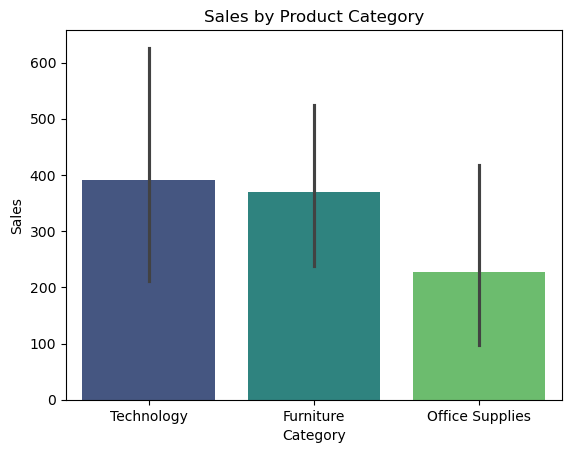

In [65]:
# Bar plort for sales by product category

sns.barplot(x='Category', y='Sales', hue='Category', data=df, palette='viridis', legend=False)
plt.title('Sales by Product Category')
plt.show()

In [66]:
#Create a new Month column from 'Order date'
df['Month'] = df['Order Date'].dt.to_period('M')

In [67]:
#Create monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum()

In [68]:
#Ensure index is in datetime format for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

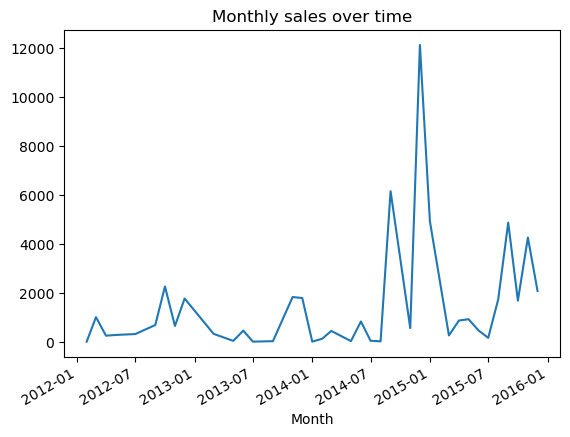

In [69]:
#Plot monthly sales over time
monthly_sales.plot(kind='line')
plt.title('Monthly sales over time')
plt.show()

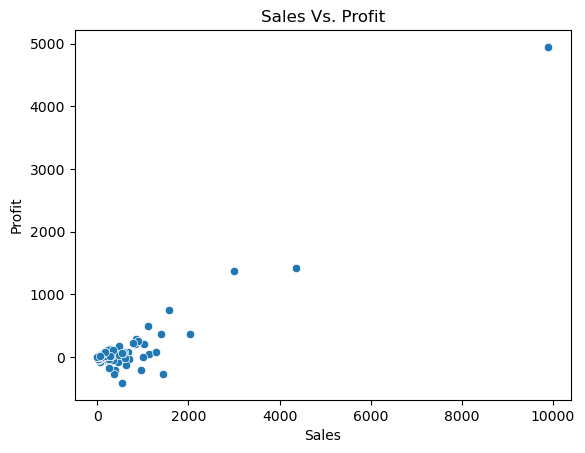

In [70]:
# Scatter plot for sales vs Profit
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales Vs. Profit')
plt.show()

In [71]:
#Pivot table for Sales by Region and Product Category
pivot_table = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')

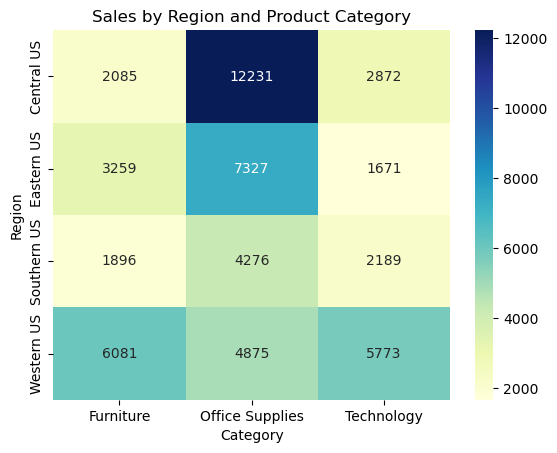

In [72]:
#Heatmap of Sales by Region and Product Category
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Sales by Region and Product Category')
plt.show()

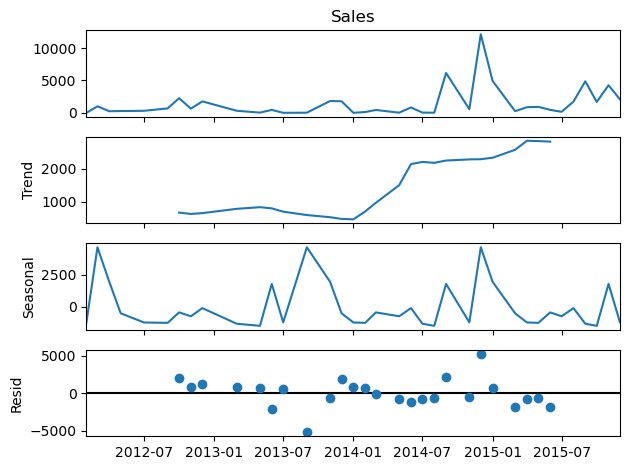

In [74]:
#Seasonal decomposition of Time Series(monthly sales)
result = seasonal_decompose(monthly_sales, model='additive', period=12)
result.plot()
plt.show()